In [4]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [5]:
RESULTS_FILE = "../../results.json"

with open(RESULTS_FILE, "r", encoding="utf-8") as f:
    data = json.load(f)

In [6]:
print(data.keys())

dict_keys(['organization', 'repositories', 'summary'])


In [7]:
summary = data["summary"]

print("Organización:", summary["organization"])
print("Repositorios totales:", summary["total_repositories"])
print("Repositorios analizados:", summary["analyzed_repositories"])
print("Repositorios no soportados:", summary["unsupported_repositories"])
print("Repositorios fallidos:", summary["failed_repositories"])
print("Hallazgos totales:", summary["total_findings"])

Organización: expressjs
Repositorios totales: 50
Repositorios analizados: 41
Repositorios no soportados: 9
Repositorios fallidos: 0
Hallazgos totales: 307


In [8]:
findings = []

for repo in data["repositories"]:

    repo_name = repo["name"]

    for finding in repo.get("findings", []):

        findings.append({
            "repository": repo_name,
            "rule_id": finding.get("rule_id"),
            "severity": finding.get("severity"),
            "message": finding.get("message"),
            "file": finding.get("file"),
            "start_line": finding.get("start_line"),
            "language": finding.get("language")
        })

df_findings = pd.DataFrame(findings)

In [9]:
df_findings.head()

,repository,rule_id,severity,message,file,start_line,language
0,badgeboard,js/prototype-pollution-utility,warning,Properties are copied from [stuff](1) to [obj]...,scripts/config.js,83,JavaScript
1,badgeboard,js/unused-local-variable,note,Unused function getUserInfo.,scripts/make-db.js,62,JavaScript
2,badgeboard,js/conditional-comment,warning,Do not use conditional comments.,static/sorttable.js,19,JavaScript
3,badgeboard,js/missing-variable-declaration,warning,"Variable the is used like a local variable, bu...",static/sorttable.js,46,JavaScript
4,badgeboard,js/missing-variable-declaration,warning,Variable sortbottomrows is used like a local v...,static/sorttable.js,59,JavaScript


In [10]:
print("Filas del DataFrame:", len(df_findings))
print("Hallazgos declarados por Miner:", data["summary"]["total_findings"])

Filas del DataFrame: 307
Hallazgos declarados por Miner: 307


In [11]:
assert len(df_findings) == data["summary"]["total_findings"]

print("Dataset cargado correctamente.")

Dataset cargado correctamente.


In [12]:
df_findings.shape

(307, 7)

In [13]:
df_findings["severity"].value_counts()

severity
note       152
warning    124
error       31
Name: count, dtype: int64

In [14]:
severity_counts = df_findings["severity"].value_counts()

severity_counts

severity
note       152
warning    124
error       31
Name: count, dtype: int64

In [15]:
severity_percentage = (
    df_findings["severity"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

severity_percentage

severity
note       49.51
warning    40.39
error      10.10
Name: proportion, dtype: float64

In [16]:
severity_summary = pd.DataFrame({
    "cantidad": severity_counts,
    "porcentaje": severity_percentage
})

severity_summary

,cantidad,porcentaje
severity,,
note,152,49.51
warning,124,40.39
error,31,10.10


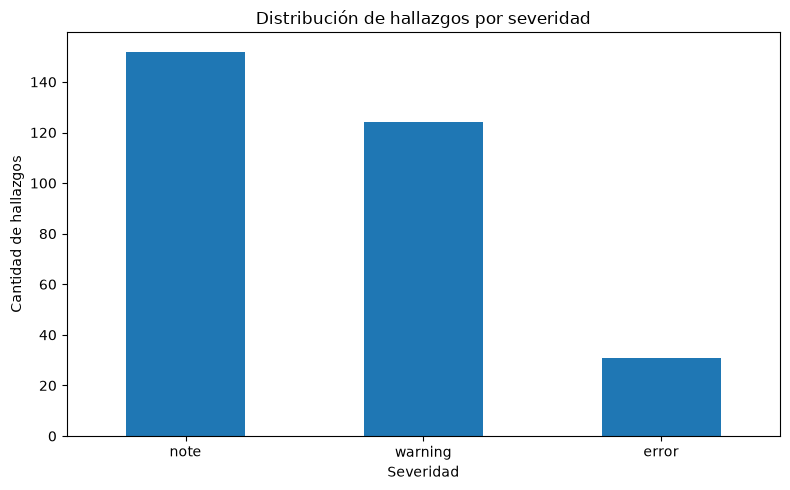

In [17]:
severity_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Distribución de hallazgos por severidad")
plt.xlabel("Severidad")
plt.ylabel("Cantidad de hallazgos")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [18]:
findings_by_repo = (
    df_findings["repository"]
    .value_counts()
)

findings_by_repo.head(10)

repository
codemod             127
badgeboard           42
express              34
vhost                17
express-expose       14
body-parser          13
perf-wg              11
urlrouter             8
express-paginate      7
connect-markdown      5
Name: count, dtype: int64

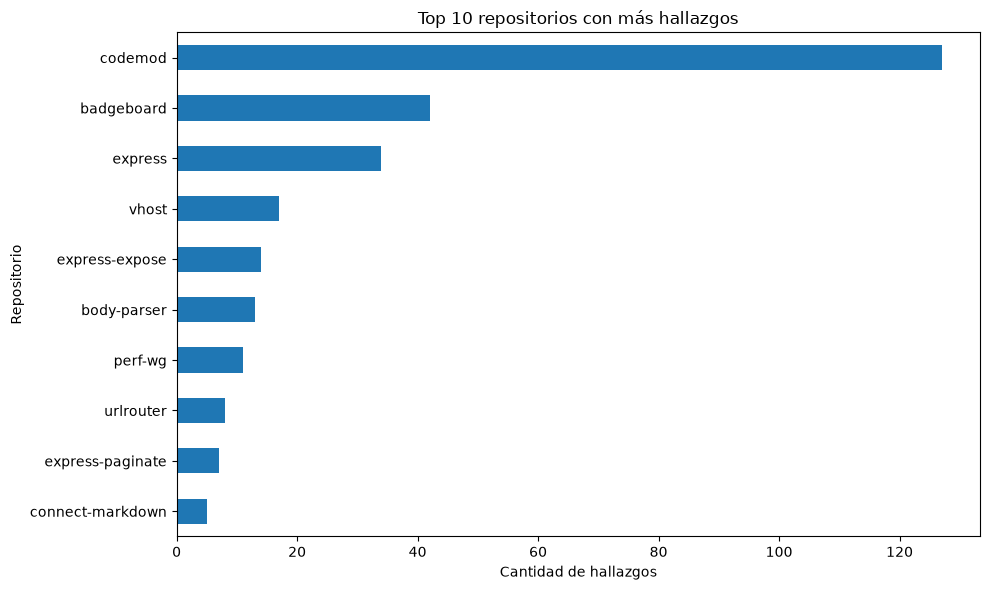

In [19]:
findings_by_repo.head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 repositorios con más hallazgos")
plt.xlabel("Cantidad de hallazgos")
plt.ylabel("Repositorio")
plt.tight_layout()

plt.show()

In [20]:
top_rules = (
    df_findings["rule_id"]
    .value_counts()
)

top_rules.head(15)

rule_id
js/unused-local-variable                  116
js/automatic-semicolon-insertion           35
js/missing-rate-limiting                   35
js/missing-variable-declaration            32
js/regex/missing-regexp-anchor             21
js/log-injection                           11
js/reflected-xss                           10
js/xss-through-exception                    4
js/clear-text-cookie                        4
js/deletion-of-non-property                 3
js/functionality-from-untrusted-domain      3
js/useless-assignment-to-local              3
js/conditional-comment                      2
js/trivial-conditional                      2
js/superfluous-trailing-arguments           2
Name: count, dtype: int64

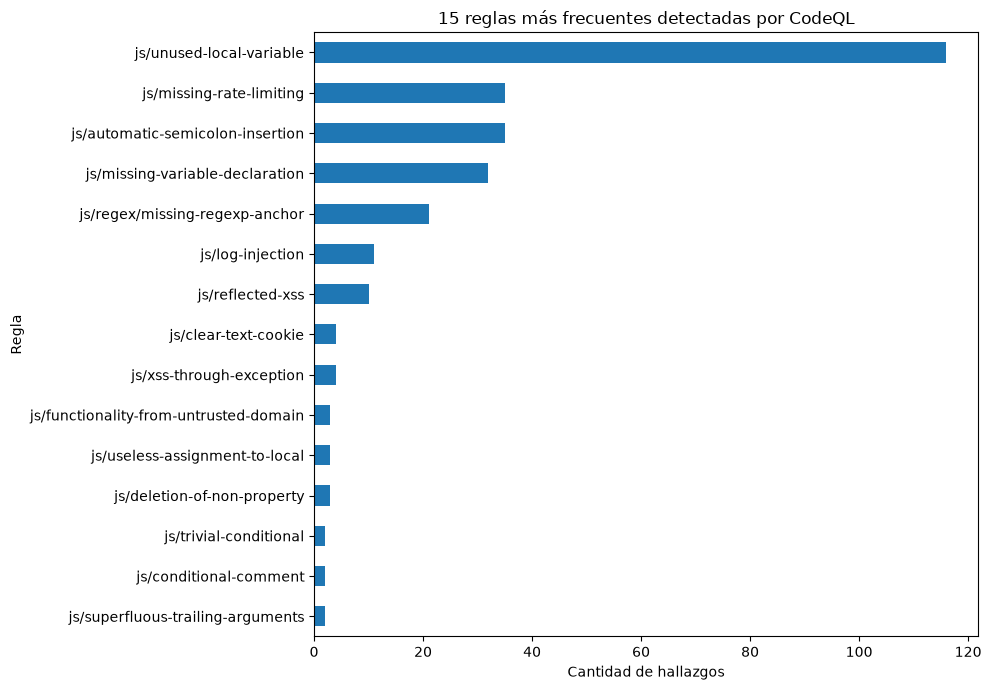

In [21]:
top_rules.head(15).sort_values().plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("15 reglas más frecuentes detectadas por CodeQL")
plt.xlabel("Cantidad de hallazgos")
plt.ylabel("Regla")
plt.tight_layout()

plt.show()

In [22]:
sorted(df_findings["rule_id"].unique())

['js/automatic-semicolon-insertion',
 'js/clear-text-cookie',
 'js/clear-text-logging',
 'js/conditional-comment',
 'js/cors-permissive-configuration',
 'js/deletion-of-non-property',
 'js/functionality-from-untrusted-domain',
 'js/incomplete-hostname-regexp',
 'js/incomplete-multi-character-sanitization',
 'js/incomplete-sanitization',
 'js/insufficient-password-hash',
 'js/log-injection',
 'js/missing-rate-limiting',
 'js/missing-token-validation',
 'js/missing-variable-declaration',
 'js/node/assignment-to-exports-variable',
 'js/path-injection',
 'js/prototype-polluting-assignment',
 'js/prototype-pollution-utility',
 'js/reflected-xss',
 'js/regex-injection',
 'js/regex/duplicate-in-character-class',
 'js/regex/missing-regexp-anchor',
 'js/remote-property-injection',
 'js/stack-trace-exposure',
 'js/superfluous-trailing-arguments',
 'js/trivial-conditional',
 'js/type-confusion-through-parameter-tampering',
 'js/unneeded-defensive-code',
 'js/unused-local-variable',
 'js/useless-a

In [24]:
security_rules = [
    "js/clear-text-cookie",
    "js/clear-text-logging",
    "js/cors-permissive-configuration",
    "js/functionality-from-untrusted-domain",
    "js/incomplete-hostname-regexp",
    "js/incomplete-multi-character-sanitization",
    "js/incomplete-sanitization",
    "js/insufficient-password-hash",
    "js/log-injection",
    "js/missing-rate-limiting",
    "js/missing-token-validation",
    "js/path-injection",
    "js/prototype-polluting-assignment",
    "js/prototype-pollution-utility",
    "js/reflected-xss",
    "js/regex-injection",
    "js/remote-property-injection",
    "js/stack-trace-exposure",
    "js/type-confusion-through-parameter-tampering",
    "js/weak-cryptographic-algorithm",
    "js/xss-through-exception"
]

In [25]:
def classify_finding(rule_id):
    if rule_id in security_rules:
        return "security"
    return "code_quality"

df_findings["category"] = df_findings["rule_id"].apply(classify_finding)

In [26]:
df_findings["category"].value_counts()

category
code_quality    222
security         85
Name: count, dtype: int64

In [27]:
df_findings["category"].value_counts(
    normalize=True
).mul(100).round(2)

category
code_quality    72.31
security        27.69
Name: proportion, dtype: float64

In [29]:
df_security = df_findings[
    df_findings["category"] == "security"
].copy()

df_security.shape

(85, 8)

In [30]:
df_security.head()

,repository,rule_id,severity,message,file,start_line,language,category
0,badgeboard,js/prototype-pollution-utility,warning,Properties are copied from [stuff](1) to [obj]...,scripts/config.js,83,JavaScript,security
42,body-parser,js/log-injection,error,Log entry depends on a [user-provided value](1).,lib/read.js,63,JavaScript,security
43,body-parser,js/log-injection,error,Log entry depends on a [user-provided value](1).,lib/read.js,193,JavaScript,security
45,body-parser,js/stack-trace-exposure,warning,This information exposed to the user depends o...,test/json.js,775,JavaScript,security
46,body-parser,js/xss-through-exception,warning,[Exception text](1) is reinterpreted as HTML w...,test/json.js,775,JavaScript,security


In [31]:
df_security["rule_id"].value_counts()

rule_id
js/missing-rate-limiting                         35
js/log-injection                                 11
js/reflected-xss                                 10
js/xss-through-exception                          4
js/clear-text-cookie                              4
js/functionality-from-untrusted-domain            3
js/path-injection                                 2
js/remote-property-injection                      2
js/type-confusion-through-parameter-tampering     2
js/prototype-pollution-utility                    1
js/stack-trace-exposure                           1
js/cors-permissive-configuration                  1
js/clear-text-logging                             1
js/incomplete-multi-character-sanitization        1
js/missing-token-validation                       1
js/insufficient-password-hash                     1
js/weak-cryptographic-algorithm                   1
js/regex-injection                                1
js/prototype-polluting-assignment                 1
js/i

In [32]:
security_severity = df_security["severity"].value_counts()

security_severity

severity
warning    54
error      31
Name: count, dtype: int64

In [33]:
security_severity_percentage = (
    df_security["severity"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

security_severity_percentage

severity
warning    63.53
error      36.47
Name: proportion, dtype: float64

In [34]:
security_severity_summary = pd.DataFrame({
    "cantidad": security_severity,
    "porcentaje": security_severity_percentage
})

security_severity_summary

,cantidad,porcentaje
severity,,
warning,54,63.53
error,31,36.47


In [35]:
security_by_repo = (
    df_security["repository"]
    .value_counts()
)

security_by_repo.head(10)

repository
codemod               40
body-parser           12
express                5
connect-markdown       4
multer                 4
perf-wg                4
urlrouter              4
session                3
connect-multiparty     2
domain-middleware      2
Name: count, dtype: int64

In [36]:
df_findings["repository"].value_counts()

repository
codemod               127
badgeboard             42
express                34
vhost                  17
express-expose         14
body-parser            13
perf-wg                11
urlrouter               8
express-paginate        7
connect-markdown        5
multer                  4
session                 4
vhostess                4
domain-middleware       3
express-namespace       3
connect-multiparty      2
restful-router          2
connect-rid             1
cors                    1
expressjs.com           1
generator               1
method-override         1
morgan                  1
serve-index             1
Name: count, dtype: int64

In [37]:
df_security["repository"].value_counts()

repository
codemod               40
body-parser           12
express                5
connect-markdown       4
multer                 4
perf-wg                4
urlrouter              4
session                3
connect-multiparty     2
domain-middleware      2
badgeboard             1
cors                   1
expressjs.com          1
method-override        1
vhost                  1
Name: count, dtype: int64

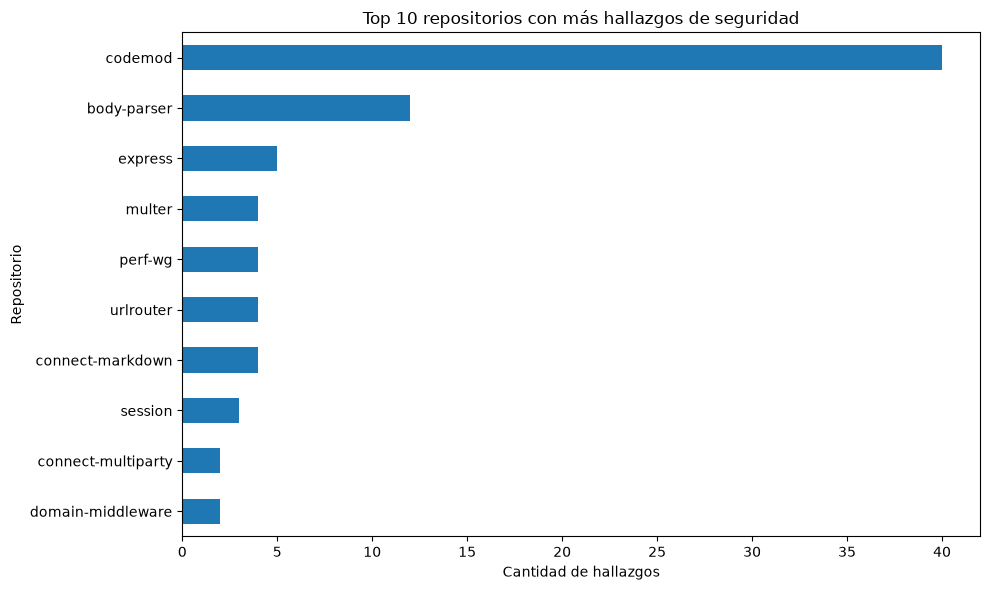

In [38]:
security_by_repo.head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 repositorios con más hallazgos de seguridad")
plt.xlabel("Cantidad de hallazgos")
plt.ylabel("Repositorio")
plt.tight_layout()

plt.show()

In [39]:
security_rules_count = (
    df_security["rule_id"]
    .value_counts()
)

security_rules_count.head(15)

rule_id
js/missing-rate-limiting                         35
js/log-injection                                 11
js/reflected-xss                                 10
js/xss-through-exception                          4
js/clear-text-cookie                              4
js/functionality-from-untrusted-domain            3
js/path-injection                                 2
js/remote-property-injection                      2
js/type-confusion-through-parameter-tampering     2
js/prototype-pollution-utility                    1
js/stack-trace-exposure                           1
js/cors-permissive-configuration                  1
js/clear-text-logging                             1
js/incomplete-multi-character-sanitization        1
js/missing-token-validation                       1
Name: count, dtype: int64

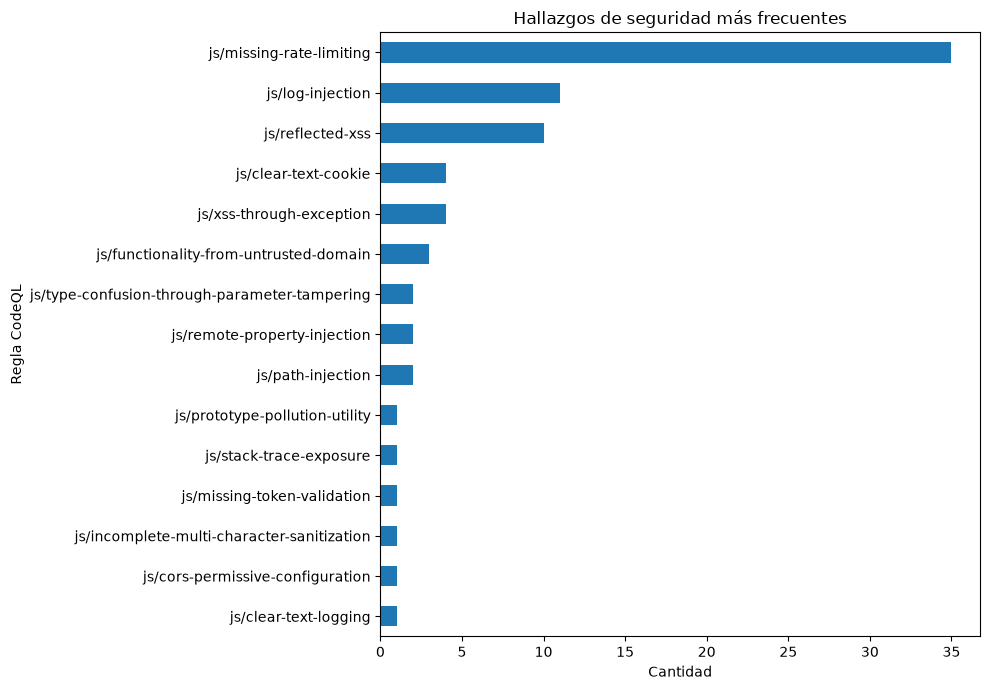

In [40]:
security_rules_count.head(15).sort_values().plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("Hallazgos de seguridad más frecuentes")
plt.xlabel("Cantidad")
plt.ylabel("Regla CodeQL")
plt.tight_layout()

plt.show()

In [41]:
df_findings["category"].value_counts()

category
code_quality    222
security         85
Name: count, dtype: int64

In [42]:
df_security["severity"].value_counts()

severity
warning    54
error      31
Name: count, dtype: int64

In [43]:
df_security["rule_id"].value_counts()

rule_id
js/missing-rate-limiting                         35
js/log-injection                                 11
js/reflected-xss                                 10
js/xss-through-exception                          4
js/clear-text-cookie                              4
js/functionality-from-untrusted-domain            3
js/path-injection                                 2
js/remote-property-injection                      2
js/type-confusion-through-parameter-tampering     2
js/prototype-pollution-utility                    1
js/stack-trace-exposure                           1
js/cors-permissive-configuration                  1
js/clear-text-logging                             1
js/incomplete-multi-character-sanitization        1
js/missing-token-validation                       1
js/insufficient-password-hash                     1
js/weak-cryptographic-algorithm                   1
js/regex-injection                                1
js/prototype-polluting-assignment                 1
js/i

In [44]:
security_by_repo = (
    df_security["repository"]
    .value_counts()
)

security_by_repo

repository
codemod               40
body-parser           12
express                5
connect-markdown       4
multer                 4
perf-wg                4
urlrouter              4
session                3
connect-multiparty     2
domain-middleware      2
badgeboard             1
cors                   1
expressjs.com          1
method-override        1
vhost                  1
Name: count, dtype: int64

In [45]:
security_by_repo.head(10)

repository
codemod               40
body-parser           12
express                5
connect-markdown       4
multer                 4
perf-wg                4
urlrouter              4
session                3
connect-multiparty     2
domain-middleware      2
Name: count, dtype: int64

In [46]:
security_by_repo.head(10)

repository
codemod               40
body-parser           12
express                5
connect-markdown       4
multer                 4
perf-wg                4
urlrouter              4
session                3
connect-multiparty     2
domain-middleware      2
Name: count, dtype: int64

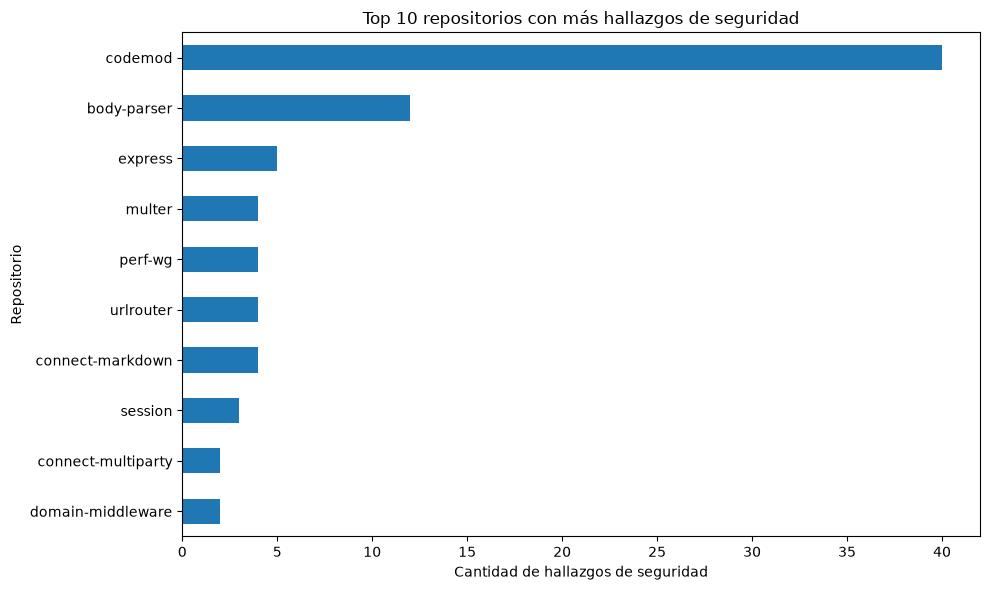

In [47]:
security_by_repo.head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 repositorios con más hallazgos de seguridad")
plt.xlabel("Cantidad de hallazgos de seguridad")
plt.ylabel("Repositorio")
plt.tight_layout()

plt.show()

In [48]:
total_by_repo = (
    df_findings["repository"]
    .value_counts()
    .rename("total_findings")
)

In [49]:
security_by_repo = (
    df_security["repository"]
    .value_counts()
    .rename("security_findings")
)

In [50]:
repo_comparison = pd.concat(
    [total_by_repo, security_by_repo],
    axis=1
).fillna(0)

In [51]:
repo_comparison["security_findings"] = (
    repo_comparison["security_findings"]
    .astype(int)
)

In [52]:
repo_comparison.head(15)

,total_findings,security_findings
repository,,
codemod,127,40
badgeboard,42,1
express,34,5
vhost,17,1
express-expose,14,0
body-parser,13,12
perf-wg,11,4
urlrouter,8,4
express-paginate,7,0


In [53]:
repo_comparison["security_percentage"] = (
    repo_comparison["security_findings"]
    / repo_comparison["total_findings"]
    * 100
).round(2)

In [54]:
repo_comparison.sort_values(
    "security_findings",
    ascending=False
).head(15)

,total_findings,security_findings,security_percentage
repository,,,
codemod,127,40,31.50
body-parser,13,12,92.31
express,34,5,14.71
perf-wg,11,4,36.36
urlrouter,8,4,50.00
connect-markdown,5,4,80.00
multer,4,4,100.00
session,4,3,75.00
connect-multiparty,2,2,100.00


In [55]:
repo_comparison.sort_values(
    "security_percentage",
    ascending=False
).head(15)

,total_findings,security_findings,security_percentage
repository,,,
expressjs.com,1,1,100.00
cors,1,1,100.00
connect-multiparty,2,2,100.00
method-override,1,1,100.00
multer,4,4,100.00
body-parser,13,12,92.31
connect-markdown,5,4,80.00
session,4,3,75.00
domain-middleware,3,2,66.67


In [56]:
repo_relevant = repo_comparison[
    repo_comparison["total_findings"] >= 5
]

In [57]:
repo_relevant.sort_values(
    "security_percentage",
    ascending=False
).head(10)

,total_findings,security_findings,security_percentage
repository,,,
body-parser,13,12,92.31
connect-markdown,5,4,80.00
urlrouter,8,4,50.00
perf-wg,11,4,36.36
codemod,127,40,31.50
express,34,5,14.71
vhost,17,1,5.88
badgeboard,42,1,2.38
express-expose,14,0,0.00


In [58]:
security_repo_rule = pd.crosstab(
    df_security["repository"],
    df_security["rule_id"]
)

security_repo_rule

rule_id,js/clear-text-cookie,js/clear-text-logging,js/cors-permissive-configuration,js/functionality-from-untrusted-domain,js/incomplete-hostname-regexp,js/incomplete-multi-character-sanitization,js/incomplete-sanitization,js/insufficient-password-hash,js/log-injection,js/missing-rate-limiting,...,js/path-injection,js/prototype-polluting-assignment,js/prototype-pollution-utility,js/reflected-xss,js/regex-injection,js/remote-property-injection,js/stack-trace-exposure,js/type-confusion-through-parameter-tampering,js/weak-cryptographic-algorithm,js/xss-through-exception
repository,,,,,,,,,,,,,,,,,,,,,
badgeboard,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
body-parser,0,0,0,0,0,0,0,0,2,0,...,0,0,0,5,0,0,1,0,0,4
codemod,0,0,0,0,0,0,0,0,6,34,...,0,0,0,0,0,0,0,0,0,0
connect-markdown,0,0,0,3,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
connect-multiparty,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0
cors,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
domain-middleware,0,0,0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
express,4,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
expressjs.com,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [59]:
top_security_rules = (
    df_security["rule_id"]
    .value_counts()
    .head(10)
    .index
)

security_repo_rule[top_security_rules]

rule_id,js/missing-rate-limiting,js/log-injection,js/reflected-xss,js/xss-through-exception,js/clear-text-cookie,js/functionality-from-untrusted-domain,js/path-injection,js/remote-property-injection,js/type-confusion-through-parameter-tampering,js/prototype-pollution-utility
repository,,,,,,,,,,
badgeboard,0,0,0,0,0,0,0,0,0,1
body-parser,0,2,5,4,0,0,0,0,0,0
codemod,34,6,0,0,0,0,0,0,0,0
connect-markdown,0,0,0,0,0,3,1,0,0,0
connect-multiparty,0,0,0,0,0,0,0,2,0,0
cors,0,0,0,0,0,0,0,0,0,0
domain-middleware,0,1,1,0,0,0,0,0,0,0
express,0,0,0,0,4,0,0,0,0,0
expressjs.com,0,0,0,0,0,0,0,0,0,0


In [60]:
security_concentration = pd.DataFrame({
    "security_findings": security_by_repo
})

In [61]:
security_concentration["percentage"] = (
    security_concentration["security_findings"]
    / security_concentration["security_findings"].sum()
    * 100
).round(2)

In [62]:
security_concentration["cumulative_percentage"] = (
    security_concentration["percentage"]
    .cumsum()
    .round(2)
)

In [63]:
security_concentration.head(10)

,security_findings,percentage,cumulative_percentage
repository,,,
codemod,40,47.06,47.06
body-parser,12,14.12,61.18
express,5,5.88,67.06
connect-markdown,4,4.71,71.77
multer,4,4.71,76.48
perf-wg,4,4.71,81.19
urlrouter,4,4.71,85.90
session,3,3.53,89.43
connect-multiparty,2,2.35,91.78


In [64]:
df_security["rule_id"].value_counts()

rule_id
js/missing-rate-limiting                         35
js/log-injection                                 11
js/reflected-xss                                 10
js/xss-through-exception                          4
js/clear-text-cookie                              4
js/functionality-from-untrusted-domain            3
js/path-injection                                 2
js/remote-property-injection                      2
js/type-confusion-through-parameter-tampering     2
js/prototype-pollution-utility                    1
js/stack-trace-exposure                           1
js/cors-permissive-configuration                  1
js/clear-text-logging                             1
js/incomplete-multi-character-sanitization        1
js/missing-token-validation                       1
js/insufficient-password-hash                     1
js/weak-cryptographic-algorithm                   1
js/regex-injection                                1
js/prototype-polluting-assignment                 1
js/i

In [65]:
security_rule_summary = pd.DataFrame({
    "cantidad": df_security["rule_id"].value_counts(),
    "porcentaje": (
        df_security["rule_id"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
})

security_rule_summary

,cantidad,porcentaje
rule_id,,
js/missing-rate-limiting,35,41.18
js/log-injection,11,12.94
js/reflected-xss,10,11.76
js/xss-through-exception,4,4.71
js/clear-text-cookie,4,4.71
js/functionality-from-untrusted-domain,3,3.53
js/path-injection,2,2.35
js/remote-property-injection,2,2.35
js/type-confusion-through-parameter-tampering,2,2.35


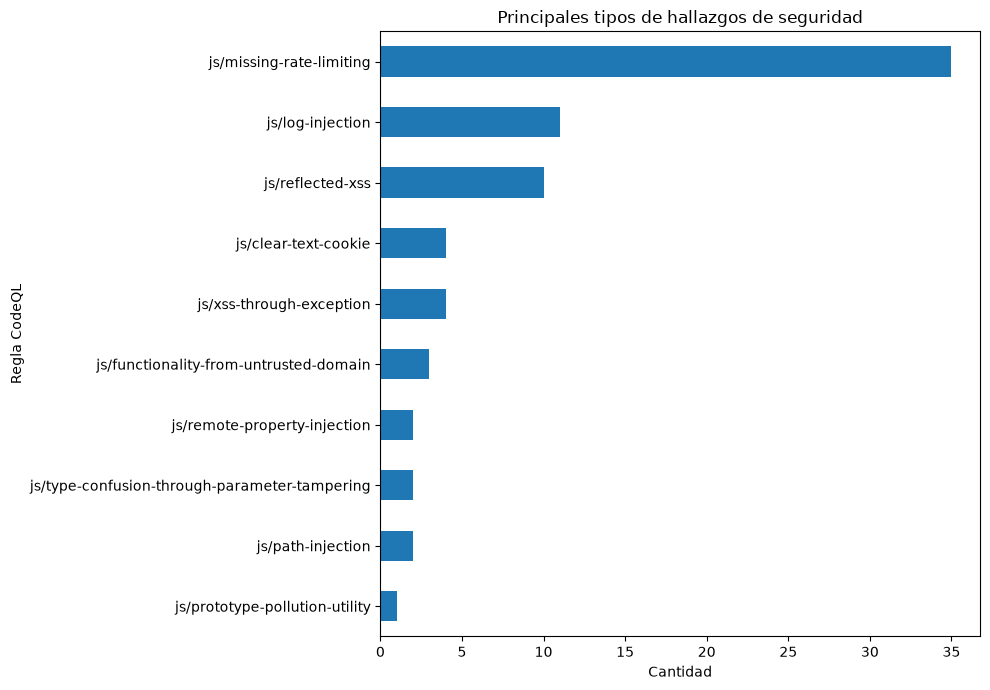

In [66]:
security_rule_summary["cantidad"].head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("Principales tipos de hallazgos de seguridad")
plt.xlabel("Cantidad")
plt.ylabel("Regla CodeQL")
plt.tight_layout()

plt.show()

In [67]:
security_by_repo

repository
codemod               40
body-parser           12
express                5
connect-markdown       4
multer                 4
perf-wg                4
urlrouter              4
session                3
connect-multiparty     2
domain-middleware      2
badgeboard             1
cors                   1
expressjs.com          1
method-override        1
vhost                  1
Name: security_findings, dtype: int64

In [68]:
repo_comparison.sort_values(
    "security_findings",
    ascending=False
).head(15)

,total_findings,security_findings,security_percentage
repository,,,
codemod,127,40,31.50
body-parser,13,12,92.31
express,34,5,14.71
perf-wg,11,4,36.36
urlrouter,8,4,50.00
connect-markdown,5,4,80.00
multer,4,4,100.00
session,4,3,75.00
connect-multiparty,2,2,100.00


In [69]:
security_concentration = pd.DataFrame({
    "security_findings": security_by_repo
})

security_concentration["percentage"] = (
    security_concentration["security_findings"]
    / security_concentration["security_findings"].sum()
    * 100
).round(2)

security_concentration["cumulative_percentage"] = (
    security_concentration["percentage"]
    .cumsum()
    .round(2)
)

security_concentration

,security_findings,percentage,cumulative_percentage
repository,,,
codemod,40,47.06,47.06
body-parser,12,14.12,61.18
express,5,5.88,67.06
connect-markdown,4,4.71,71.77
multer,4,4.71,76.48
perf-wg,4,4.71,81.19
urlrouter,4,4.71,85.90
session,3,3.53,89.43
connect-multiparty,2,2.35,91.78


In [70]:
repo_relevant = repo_comparison[
    repo_comparison["total_findings"] >= 5
].copy()

repo_relevant.sort_values(
    "security_percentage",
    ascending=False
)

,total_findings,security_findings,security_percentage
repository,,,
body-parser,13,12,92.31
connect-markdown,5,4,80.00
urlrouter,8,4,50.00
perf-wg,11,4,36.36
codemod,127,40,31.50
express,34,5,14.71
vhost,17,1,5.88
badgeboard,42,1,2.38
express-expose,14,0,0.00


In [71]:
repo_relevant["risk_score"] = (
    repo_relevant["security_findings"]
    * (repo_relevant["security_percentage"] / 100)
).round(2)

repo_relevant.sort_values(
    "risk_score",
    ascending=False
)

,total_findings,security_findings,security_percentage,risk_score
repository,,,,
codemod,127,40,31.50,12.60
body-parser,13,12,92.31,11.08
connect-markdown,5,4,80.00,3.20
urlrouter,8,4,50.00,2.00
perf-wg,11,4,36.36,1.45
express,34,5,14.71,0.74
vhost,17,1,5.88,0.06
badgeboard,42,1,2.38,0.02
express-expose,14,0,0.00,0.00


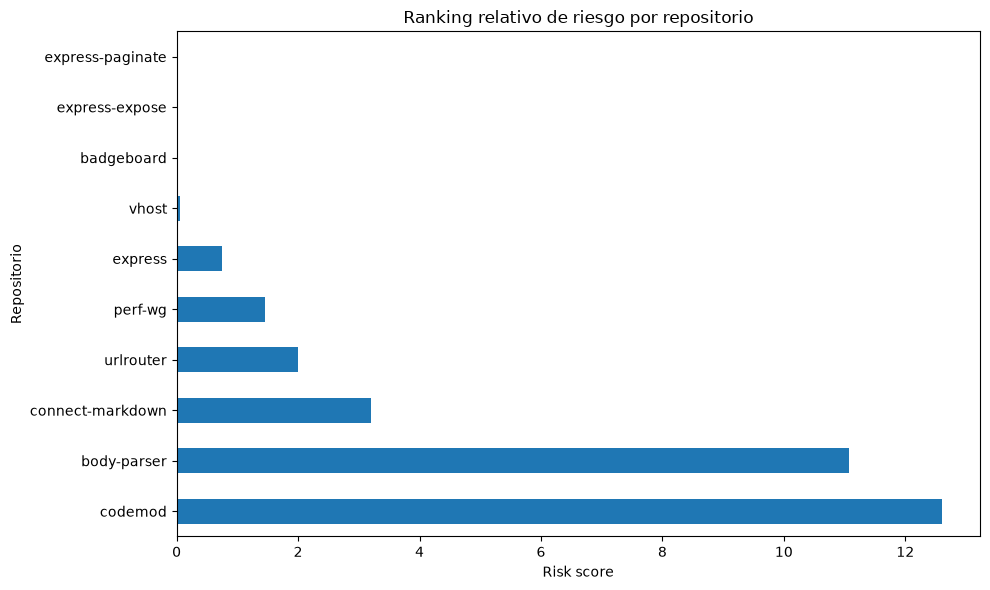

In [72]:
repo_relevant.sort_values(
    "risk_score",
    ascending=False
)["risk_score"].plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Ranking relativo de riesgo por repositorio")
plt.xlabel("Risk score")
plt.ylabel("Repositorio")
plt.tight_layout()

plt.show()

In [75]:
from pathlib import Path

OUTPUT_DIR = Path("../output")
OUTPUT_DIR.mkdir(exist_ok=True)

df_findings.to_csv(
    OUTPUT_DIR / "findings.csv",
    index=False
)

df_security.to_csv(
    OUTPUT_DIR / "security_findings.csv",
    index=False
)

repo_comparison.to_csv(
    OUTPUT_DIR / "repository_comparison.csv"
)

security_concentration.to_csv(
    OUTPUT_DIR / "security_concentration.csv"
)

In [76]:
repo_comparison.reset_index().to_json(
    OUTPUT_DIR / "repository_comparison.json",
    orient="records",
    indent=2
)

security_concentration.reset_index().to_json(
    OUTPUT_DIR / "security_concentration.json",
    orient="records",
    indent=2
)